# XRI simulator tutorial at API (06-02-2026)

This notebook serves as a quick example of how to use the simulator for X-ray interferometric observations. We start from a source model consisting of two point sources with AGN-like X-ray spectra in the energy range of 0.5 to 10 keV, and with default instrumental files (ARF and RMF - Ancillary Response and Response Matrix Files respectively), that approximate the properties of Pt-coated Si pore optics and CMOS imaging sensors as envisioned for an XRI mission. 

**Disclaimer: This code is still being developed and is not yet suited for an alpha release. This tutorial therefore includes a few hacks and apart from this notebook, no sufficient documentation. Please do not distribute this repository any further for now**

## Dependencies and related external packages 

* Python version >= 3.10
* Standard computing and plotting packages: `numpy`, `scipy`, `matplotlib`
* `astropy` (especially for handling of fits files)





In [21]:
import sys

import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from astropy.table import QTable
import scipy.constants as spc
# from ndspec.Response import ResponseMatrix

sys.path.append("./modules/")

plt.style.use('./xri_plot_white.mplstyle')

# XRI simulator imports
import images
import instrument
import process 
import analysis

%matplotlib widget

plt.close('all')

## Model inspection

The model includes two point sources with an angular separation of $\sim 400 \,\text{µas}$ and simple AGN-like spectra. Its fits file conforms to the SIMPUT format. In the following two cells we will inspect this model. 

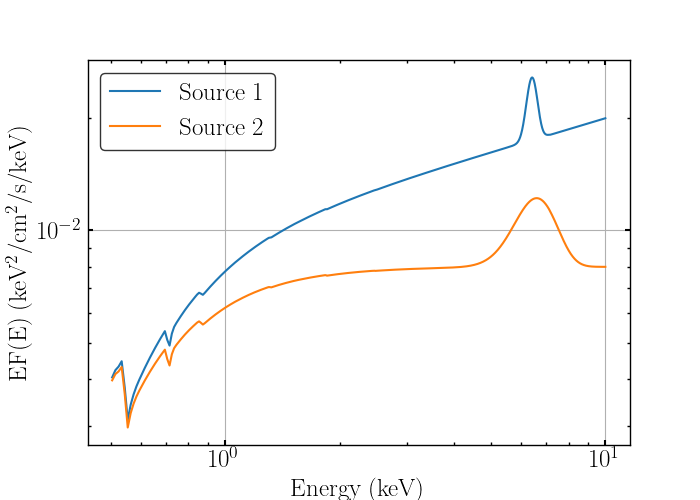

In [2]:
src_file = 'model/double_point_source.fits'


hdul = fits.open(src_file)
src_catalog = hdul['SRC_CAT'].data
spectrum_data = hdul['SPECTRUM'].data
hdul.close()
plt.figure(figsize=(7,5))
plt.plot(spectrum_data['ENERGY'][0], spectrum_data['FLUXDENSITY'][0] * spectrum_data['ENERGY'][0]**2, label='Source 1')
plt.plot(spectrum_data['ENERGY'][1], spectrum_data['FLUXDENSITY'][1] * spectrum_data['ENERGY'][1]**2, label='Source 2')
plt.xlabel('Energy (keV)')
plt.ylabel('EF(E) (keV$^2$/cm$^2$/s/keV)')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.legend()
plt.show()

The two absorbed spectra show similar features, apart from source 1 having a higher overall flux and a narrower modeled iron line at $6.4$ keV.

## Instrument response

Next, we take a look at the instrumental files that have been created for a specific XRI setup consisting of linearly spaced baselines in the range $0.05\,\textrm{m} - 1\,\textrm{m}$. The effective area per baseline as well as the total effective area of the instrument are included in the ARF and the redistribution properties of the detector are stored in the RMF. These files were generated by assuming Pt-coated Si pore optics and THESEUS-SXI-like CMOS detectors to be used on an XRI mission.

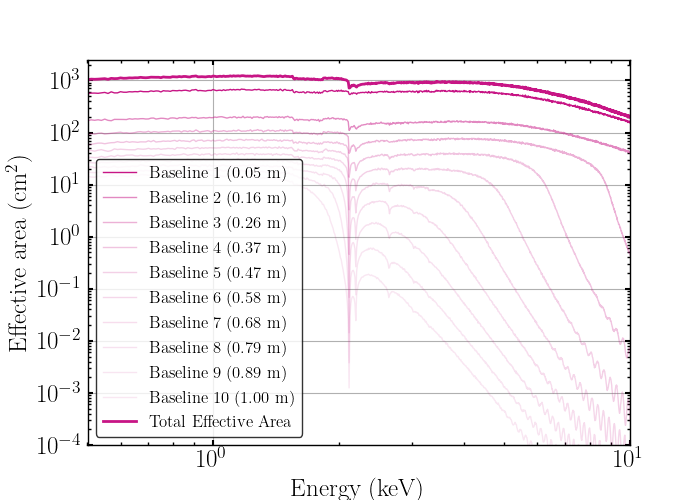

In [3]:
arf_path = 'instrumental/arf.fits'
rmf_path = 'instrumental/rmf.fits'

instrument.plot_arf(arf_path, baseline_mode=True)

The plot above shows that the effective area per baseline varies significantly. This is due to the smaller baselines allowing shallower grazing angles and therefore higher reflectance of corresponding mirror surfaces, and is dominant over pure projection effects, where the effect is vice-versa. Below the instrument response is visualized, and it is evident that the model of the soft X-ray CMOS chip includes only the photo-, escape-, and fluorescence-peak (on top of a constant noisy contribution). 

To run the cell below, your environment must include a working [nDspec](https://github.com/nDspec/nDspec) installation. Please skip this cell, if this is not the case.

In [4]:
# matrix = ResponseMatrix(rmf_path)
# matrix.load_arf(arf_path)
# resp_fig = matrix.plot_response(plot_type='energy', return_plot=True)

## Detected Photons

The model and instrumental files discussed so far allow us to sample photons from the instrument-folded spectra. Since a separate ARF per baseline is in place, sampled photons are assigned their baselines with the effective area as probability filter. Subsequently, the RMF is applied leading to the sampled photon energies to be discretized and smeared-out.

In [5]:
exposure_time = 1e4  # seconds
process.generate_event_list(src_file, arf_path, rmf_path, exposure_time, output_file='event_list.fits')

Total photons generated: 280533


Let us now take a look at the photons, that have been sampled by the `process.generate_event_list()` function. We will visualize the sampled spectra per baseline as for the ARF before. The result shows the average spectrum of both sources folded by the instrument response. It is evident that larger baselines detect almost no photons above $\sim5$ keV.

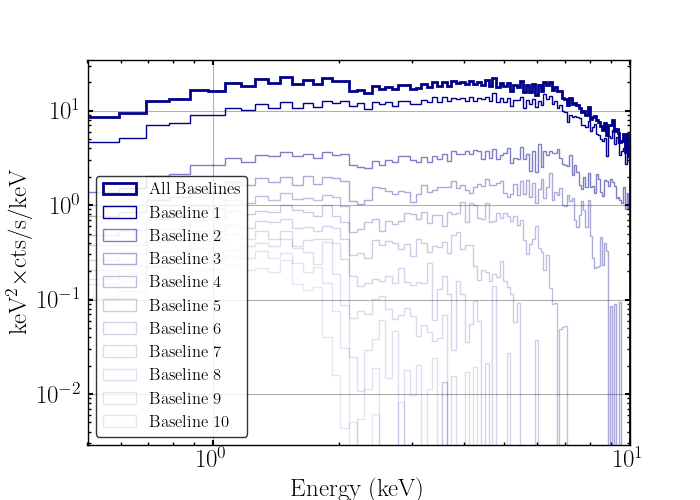

In [6]:
event_list = 'event_list.fits'
analysis.plot_spec_per_baseline(event_list, exposure_time)

## Setting up the interferometer

To start a simulation, we first create an image object, representing the sampled photons, and an instrument object. Although the ARF already includes information about our baseline composition, we need to extract it again, since the instrument object requires baselines to be added separately. In addition, we add the roller specification, to make our interferometer rotate while observing, such that the $uv$-plane is filled in.

The last step in this cell is to call the `process.interferometer_data()` function to calculate the detector impact locations of photons.

In [34]:
# open ARF to extract baseline information
hdul = fits.open(event_list)
event_data = hdul[1].data
hdul.close()

# get baselines in meter from headers of ARF extensions
hdul = fits.open('instrumental/arf.fits')
baseline_list = []
num_baselines = len(hdul) - 2
for i in range(num_baselines):
    ext_name = f'SPECRESP_BL{i+1}'
    baseline = hdul[ext_name].header['BASELINE']
    baseline_list.append(baseline)
hdul.close()

# create image object readable by process module from event list
img = images.create_image_from_events(event_data)

# initialize interferometer and add baselines
inst = instrument.interferometer(roller = instrument.interferometer.smooth_roller)
for b in baseline_list:
    inst.add_willingale_baseline(b)

# calculate interferograms for each baseline
data = process.interferometer_data(inst, img)



## Image reconstruction

Having the positional data and detected energies stored in the data object, we can now filter for specific energy ranges or baselines. But first, let's look at the reconstructed image made from all detected photons, i.e. all baselines and energies. In the current version of the simulator, we still have to specify a single FoV value that is used for plotting and projection of the reconstructed image on a pixel grid. 

In [35]:
fov = 2e-3
rec_img, uv, inf_data = analysis.image_recon_smooth(data, inst, fov=fov, recon_type='IFFT')

Processing baseline 1 / 10
Number of photons in baseline: 163357
Calculating uv coordinates and fourier values...
Baseline 1 processed.

Processing baseline 2 / 10
Number of photons in baseline: 46174
Calculating uv coordinates and fourier values...
Baseline 2 processed.

Processing baseline 3 / 10
Number of photons in baseline: 24252
Calculating uv coordinates and fourier values...
Baseline 3 processed.

Processing baseline 4 / 10
Number of photons in baseline: 14691
Calculating uv coordinates and fourier values...
Baseline 4 processed.

Processing baseline 5 / 10
Number of photons in baseline: 10190
Calculating uv coordinates and fourier values...
Baseline 5 processed.

Processing baseline 6 / 10
Number of photons in baseline: 7089
Calculating uv coordinates and fourier values...
Baseline 6 processed.

Processing baseline 7 / 10
Number of photons in baseline: 5272
Calculating uv coordinates and fourier values...
Baseline 7 processed.

Processing baseline 8 / 10
Number of photons in b

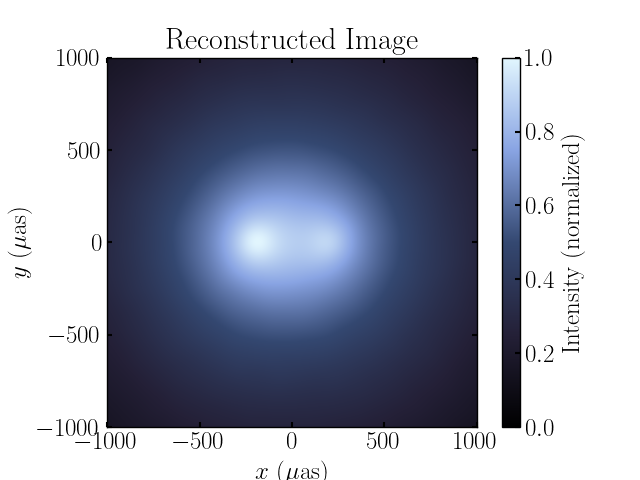

In [36]:
analysis.plot_inf_image(rec_img, fov_arcsec=fov)

We can see that the two point sources are barely resolved, which is due to the equal weighting of photons in the reconstruction process. As most photons are detected in soft X-rays and the effective area of smaller baselines is largest, the spatial resolution apparent is limited. However, filtering for larger baselines (in this case the largest 3) and re-running the reconstruction allows a higher resolution image to be created. 

Events in filtered data: 4000


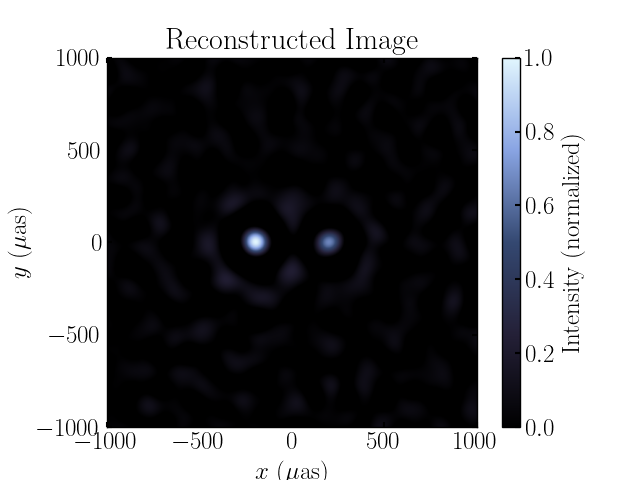

In [37]:
# filter data to given energy range and baselines
data_filt = analysis.filter_data(data, (1.0, 10.), baseline_bounds= (7, 9))
rec_img_filt, uv_filt, inf_data_filt = analysis.image_recon_smooth(data_filt, inst, fov=fov, recon_type='IFFT', verbose=False)
analysis.plot_inf_image(rec_img_filt, fov_arcsec=fov)

Now double point sources are clearly resolved. Let's see how far we can push our resolution by filtering for higher energies.

Events in filtered data: 85


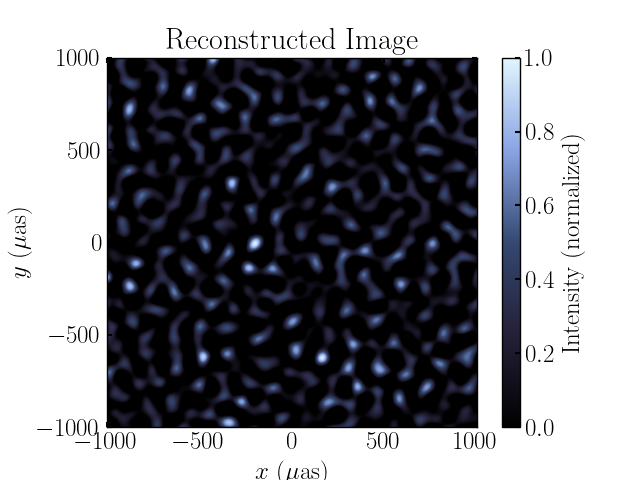

In [38]:
data_filt2 = analysis.filter_data(data, (2.0, 10.), baseline_bounds= (7, 9))
rec_img_filt2, uv_filt2, inf_data_filt2 = analysis.image_recon_smooth(data_filt2, inst, fov=fov, recon_type='IFFT', verbose=False)
analysis.plot_inf_image(rec_img_filt2, fov_arcsec=fov)

Again, we see that larger baselines are much more effective in capturing soft X-rays, increasing the lower bound of our energy range from $1.0$ to $2.0$ keV only leaves 85 photons for reconstruction. Hence, the reconstructed image becomes much 'dirtier'.

Note that the current baseline set up, where the geometric mirror area is equally distributed between baseliens was chosen for its simplicity and for illustrative purposes. An actual mission will most likely have an instrumental design enabling more effective area in hard X-rays and therefore higher spatial resolution.

As a last step, we will plot an interactive figure, where we can scan through wavelengths.

In [48]:
def interactive_plot(data, inst, fov):
    from ipywidgets import interactive
    def plot_func(emin, emax, bmin, bmax):
        plt.close('all')
        data_filt = analysis.filter_data(data, (emin, emax), baseline_bounds= (bmin, bmax))
        rec_img_filt, _, _ = analysis.image_recon_smooth(data_filt, inst, fov=fov, recon_type='IFFT', verbose=False)
        analysis.plot_inf_image(rec_img_filt, fov_arcsec=fov)
    interactive_plot = interactive(plot_func, emin=(0.1, 10., 0.1), emax=(0.1, 10., 0.1), bmin=(0, len(inst.baselines)-1), bmax=(0, len(inst.baselines)-1))

    # set default values for the interactive plot
    interactive_plot.children[0].value = 1.5
    interactive_plot.children[1].value = 10.0
    interactive_plot.children[2].value = 0
    interactive_plot.children[3].value = 9
    return interactive_plot

interactive_plot(data, inst, fov)

interactive(children=(FloatSlider(value=0.5, description='emin', max=10.0, min=0.1), FloatSlider(value=10.0, d…